<a href="https://colab.research.google.com/github/Arnauld83/Grammy_Awards/blob/main/Inclusion_Financi%C3%A8re_des_micro_Entrepreneurs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Prédiction de l'Inclusion Financière des Micro-Entrepreneurs

**Projet de Machine Learning sur données tabulaires**

**Membres du groupe :**
- Kalala Kayembe Armel
- Kabeya Muleba Arnauld

---

## 🎯 Objectif
Développer un modèle de Machine Learning capable de prédire si une personne possède un **compte bancaire** (proxy de l'inclusion financière) à partir de caractéristiques socio-économiques, puis identifier les facteurs les plus influents.

**Jeu de données :** *Financial Inclusion in Africa* (enquêtes Finscope 2016-2018, Kenya, Rwanda, Tanzanie, Ouganda) — environ 23 500 individus.

## 🧭 Méthodologie
1. Acquisition des données
2. Prétraitement des données
3. Analyse exploratoire (EDA)
4. Encodage des variables catégorielles
5. Construction de plusieurs modèles de Machine Learning
6. Évaluation et comparaison des performances
7. Sélection du meilleur modèle & analyse des variables importantes


## 0. Importation des bibliothèques

In [ ]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement & Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Bibliothèques importées avec succès ✅")


Bibliothèques importées avec succès ✅


## 1. Acquisition des données

Le jeu de données provient de l'enquête **Financial Inclusion in Africa** (Finscope), largement utilisé pour ce type d'étude sur l'inclusion financière. Il est chargé directement depuis une source publique (GitHub), aucun téléversement manuel n'est nécessaire.

In [ ]:
URL_DONNEES = "https://raw.githubusercontent.com/abdullahi-abubakar/Financial-Inclusion-in-Africa/master/Train_v2.csv"
URL_SECOURS = "https://github.com/abdullahi-abubakar/Financial-Inclusion-in-Africa/raw/refs/heads/master/Train_v2.csv"

try:
    df = pd.read_csv(URL_DONNEES)
except Exception as e:
    print("Source principale indisponible, tentative avec l'URL de secours...", e)
    df = pd.read_csv(URL_SECOURS)

print(f"Dimensions du jeu de données : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Dimensions du jeu de données : 23524 lignes x 13 colonnes


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## 2. Traduction des caractéristiques en français

Le jeu de données original est en anglais. On traduit ici les **noms de colonnes** ainsi que les **valeurs catégorielles** afin de travailler entièrement en français.

In [ ]:
# --- Traduction des noms de colonnes ---
traduction_colonnes = {
    "country": "pays",
    "year": "annee",
    "uniqueid": "identifiant_unique",
    "bank_account": "compte_bancaire",
    "location_type": "type_localisation",
    "cellphone_access": "acces_telephone",
    "household_size": "taille_menage",
    "age_of_respondent": "age_repondant",
    "gender_of_respondent": "genre_repondant",
    "relationship_with_head": "lien_avec_chef_menage",
    "marital_status": "statut_matrimonial",
    "education_level": "niveau_education",
    "job_type": "type_emploi",
}

df = df.rename(columns=traduction_colonnes)
print("Nouvelles colonnes :", list(df.columns))


Nouvelles colonnes : ['pays', 'annee', 'identifiant_unique', 'compte_bancaire', 'type_localisation', 'acces_telephone', 'taille_menage', 'age_repondant', 'genre_repondant', 'lien_avec_chef_menage', 'statut_matrimonial', 'niveau_education', 'type_emploi']


In [ ]:
# --- Traduction des valeurs catégorielles ---
traduction_valeurs = {
    "pays": {
        "Kenya": "Kenya", "Rwanda": "Rwanda",
        "Tanzania": "Tanzanie", "Uganda": "Ouganda"
    },
    "compte_bancaire": {"Yes": "Oui", "No": "Non"},
    "type_localisation": {"Rural": "Rural", "Urban": "Urbain"},
    "acces_telephone": {"Yes": "Oui", "No": "Non"},
    "genre_repondant": {"Male": "Homme", "Female": "Femme"},
    "lien_avec_chef_menage": {
        "Head of Household": "Chef de ménage",
        "Spouse": "Conjoint(e)",
        "Child": "Enfant",
        "Parent": "Parent",
        "Other relative": "Autre membre de la famille",
        "Other non-relatives": "Sans lien de parenté"
    },
    "statut_matrimonial": {
        "Married/Living together": "Marié(e) / Concubinage",
        "Widowed": "Veuf / Veuve",
        "Single/Never Married": "Célibataire",
        "Divorced/Seperated": "Divorcé(e) / Séparé(e)",
        "Dont know": "Ne sait pas"
    },
    "niveau_education": {
        "No formal education": "Aucune éducation formelle",
        "Primary education": "Éducation primaire",
        "Secondary education": "Éducation secondaire",
        "Vocational/Specialised training": "Formation professionnelle",
        "Tertiary education": "Éducation supérieure",
        "Other/Dont know/RTA": "Autre / Ne sait pas"
    },
    "type_emploi": {
        "Farming and Fishing": "Agriculture et pêche",
        "Self employed": "Travailleur indépendant",
        "Formally employed Government": "Employé formel (Gouvernement)",
        "Formally employed Private": "Employé formel (Privé)",
        "Informally employed": "Employé informel",
        "Remittance Dependent": "Dépendant des transferts d'argent",
        "Government Dependent": "Dépendant de l'aide gouvernementale",
        "Other Income": "Autre revenu",
        "No Income": "Sans revenu",
        "Dont Know/Refuse to answer": "Ne sait pas / Refuse de répondre"
    }
}

for colonne, mapping in traduction_valeurs.items():
    if colonne in df.columns:
        df[colonne] = df[colonne].replace(mapping)

df.head()


,pays,annee,identifiant_unique,compte_bancaire,type_localisation,acces_telephone,taille_menage,age_repondant,genre_repondant,lien_avec_chef_menage,statut_matrimonial,niveau_education,type_emploi
0,Kenya,2018,uniqueid_1,Oui,Rural,Oui,3,24,Femme,Conjoint(e),Marié(e) / Concubinage,Éducation secondaire,Travailleur indépendant
1,Kenya,2018,uniqueid_2,Non,Rural,Non,5,70,Femme,Chef de ménage,Veuf / Veuve,Aucune éducation formelle,Dépendant de l'aide gouvernementale
2,Kenya,2018,uniqueid_3,Oui,Urbain,Oui,5,26,Homme,Autre membre de la famille,Célibataire,Formation professionnelle,Travailleur indépendant
3,Kenya,2018,uniqueid_4,Non,Rural,Oui,5,34,Femme,Chef de ménage,Marié(e) / Concubinage,Éducation primaire,Employé formel (Privé)
4,Kenya,2018,uniqueid_5,Non,Urbain,Non,8,26,Homme,Enfant,Célibataire,Éducation primaire,Employé informel


## 3. Exploration initiale des données

In [ ]:
print("Informations générales :")
df.info()


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   pays                   23524 non-null  object
 1   annee                  23524 non-null  int64 
 2   identifiant_unique     23524 non-null  object
 3   compte_bancaire        23524 non-null  object
 4   type_localisation      23524 non-null  object
 5   acces_telephone        23524 non-null  object
 6   taille_menage          23524 non-null  int64 
 7   age_repondant          23524 non-null  int64 
 8   genre_repondant        23524 non-null  object
 9   lien_avec_chef_menage  23524 non-null  object
 10  statut_matrimonial     23524 non-null  object
 11  niveau_education       23524 non-null  object
 12  type_emploi            23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [ ]:
print("Statistiques descriptives (variables numériques) :")
df.describe()


Statistiques descriptives (variables numériques) :


,annee,taille_menage,age_repondant
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


In [ ]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nNombre de doublons :", df.duplicated().sum())


Valeurs manquantes par colonne :
pays                     0
annee                    0
identifiant_unique       0
compte_bancaire          0
type_localisation        0
acces_telephone          0
taille_menage            0
age_repondant            0
genre_repondant          0
lien_avec_chef_menage    0
statut_matrimonial       0
niveau_education         0
type_emploi              0
dtype: int64

Nombre de doublons : 0


## 4. Prétraitement des données

- Suppression de l'identifiant unique (non prédictif)
- Suppression des doublons éventuels
- Vérification/traitement des valeurs manquantes

In [ ]:
# Suppression des doublons
df = df.drop_duplicates()

# Suppression de la colonne identifiant (non pertinente pour la prédiction)
df_model = df.drop(columns=["identifiant_unique"])

# Suppression des lignes avec valeurs manquantes restantes (le jeu de données en contient très peu)
df_model = df_model.dropna()

print(f"Dimensions après nettoyage : {df_model.shape[0]} lignes x {df_model.shape[1]} colonnes")


Dimensions après nettoyage : 23524 lignes x 12 colonnes


## 5. Analyse exploratoire des données (EDA)

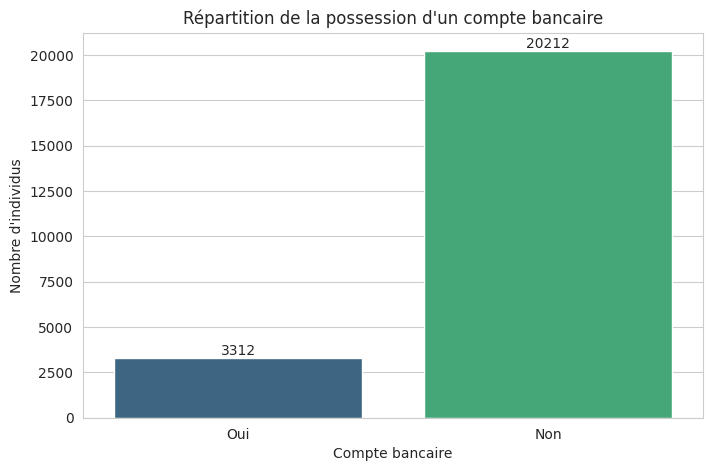

compte_bancaire
Non    85.920762
Oui    14.079238
Name: proportion, dtype: float64


In [ ]:
# Répartition de la variable cible : compte_bancaire
plt.figure()
ax = sns.countplot(data=df_model, x="compte_bancaire", palette="viridis")
plt.title("Répartition de la possession d'un compte bancaire")
plt.xlabel("Compte bancaire")
plt.ylabel("Nombre d'individus")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df_model["compte_bancaire"].value_counts(normalize=True) * 100)


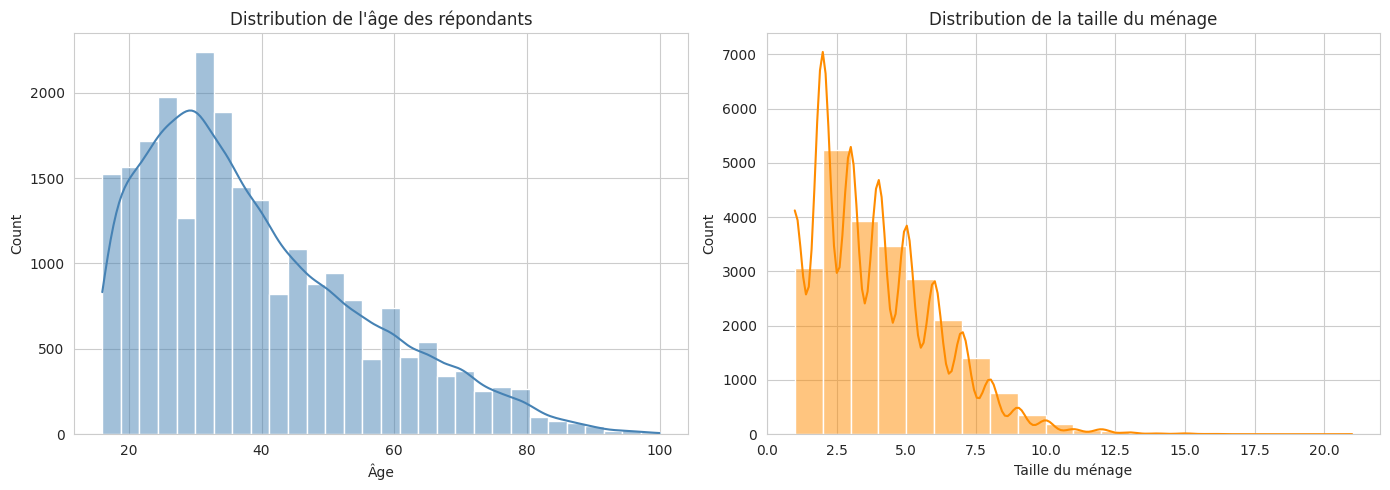

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model["age_repondant"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de l'âge des répondants")
axes[0].set_xlabel("Âge")

sns.histplot(df_model["taille_menage"], bins=20, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution de la taille du ménage")
axes[1].set_xlabel("Taille du ménage")

plt.tight_layout()
plt.show()


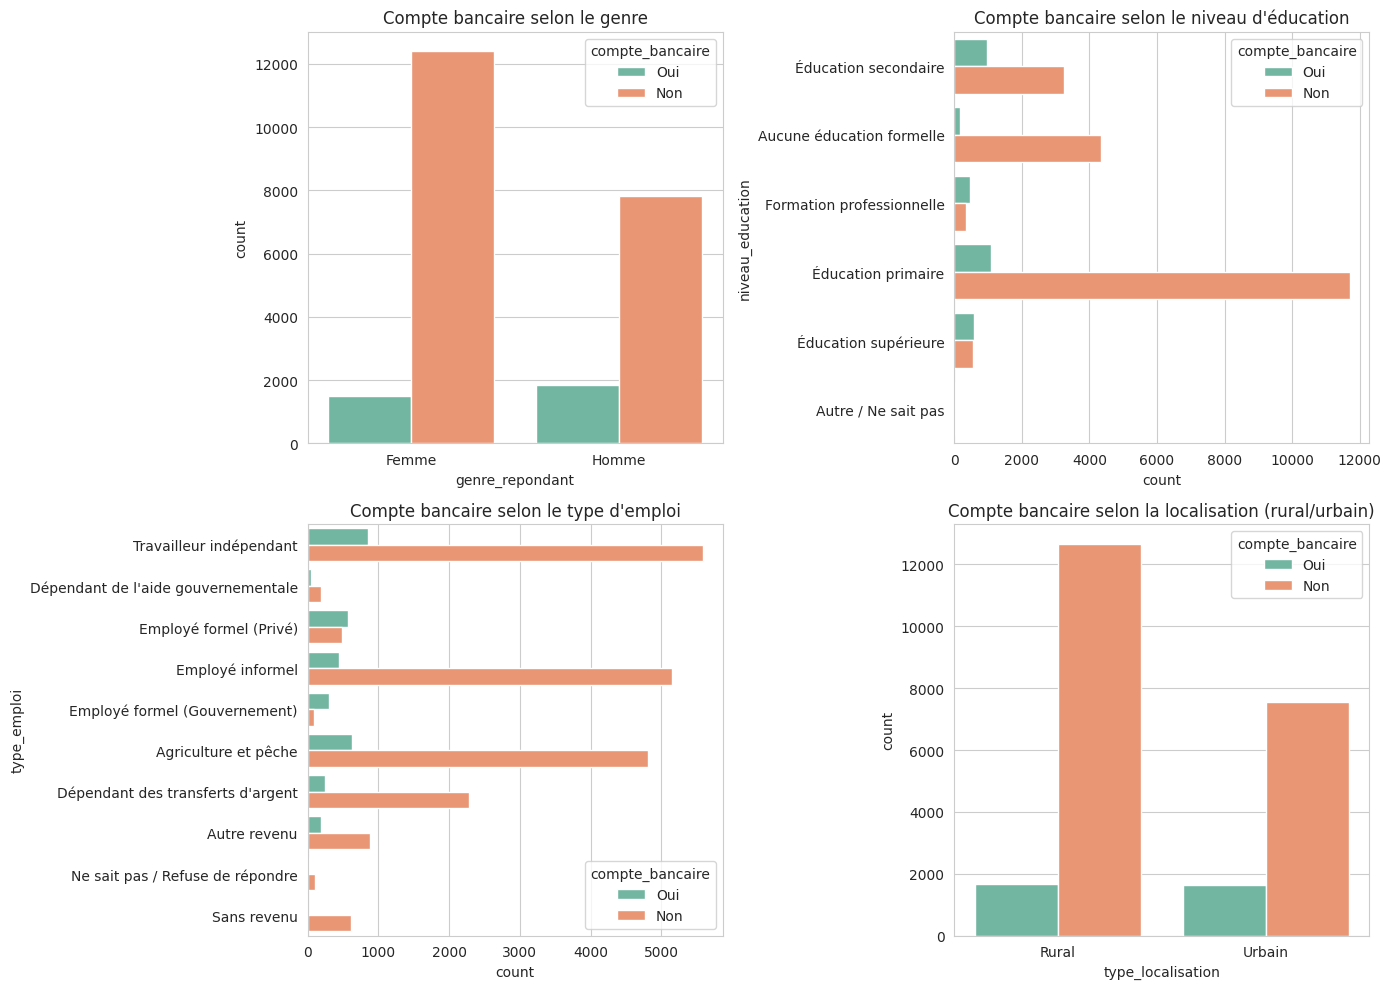

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_model, x="genre_repondant", hue="compte_bancaire", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Compte bancaire selon le genre")

sns.countplot(data=df_model, y="niveau_education", hue="compte_bancaire", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Compte bancaire selon le niveau d'éducation")

sns.countplot(data=df_model, y="type_emploi", hue="compte_bancaire", ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Compte bancaire selon le type d'emploi")

sns.countplot(data=df_model, x="type_localisation", hue="compte_bancaire", ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Compte bancaire selon la localisation (rural/urbain)")

plt.tight_layout()
plt.show()


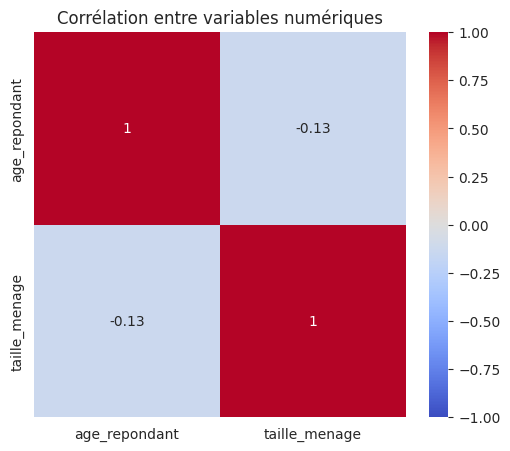

In [ ]:
plt.figure(figsize=(6, 5))
correlation = df_model[["age_repondant", "taille_menage"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre variables numériques")
plt.show()


## 6. Encodage des variables catégorielles

On transforme la variable cible en binaire (1 = Oui, 0 = Non) et on encode les variables explicatives catégorielles à l'aide du **Label Encoding**.

In [ ]:
df_encoded = df_model.copy()

# Variable cible en binaire
df_encoded["compte_bancaire"] = df_encoded["compte_bancaire"].map({"Oui": 1, "Non": 0})

# Encodage des variables catégorielles explicatives
colonnes_categorielles = df_encoded.select_dtypes(include="object").columns.tolist()
print("Colonnes catégorielles à encoder :", colonnes_categorielles)

encodeurs = {}
for col in colonnes_categorielles:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encodeurs[col] = le

df_encoded.head()


Colonnes catégorielles à encoder : ['pays', 'type_localisation', 'acces_telephone', 'genre_repondant', 'lien_avec_chef_menage', 'statut_matrimonial', 'niveau_education', 'type_emploi']


,pays,annee,compte_bancaire,type_localisation,acces_telephone,taille_menage,age_repondant,genre_repondant,lien_avec_chef_menage,statut_matrimonial,niveau_education,type_emploi
0,0,2018,1,0,1,3,24,0,2,2,4,9
1,0,2018,0,0,0,5,70,0,1,4,0,2
2,0,2018,1,1,1,5,26,1,0,0,2,9
3,0,2018,0,0,1,5,34,0,1,2,3,5
4,0,2018,0,1,0,8,26,1,3,0,3,6


## 7. Séparation en jeu d'entraînement / test et normalisation

In [ ]:
X = df_encoded.drop(columns=["compte_bancaire"])
y = df_encoded["compte_bancaire"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]}")
print(f"Taille du jeu de test : {X_test.shape[0]}")


Taille du jeu d'entraînement : 18819
Taille du jeu de test : 4705


## 8. Construction des modèles de Machine Learning

Plusieurs modèles sont entraînés puis comparés :
- Régression Logistique
- Arbre de Décision
- Forêt Aléatoire (Random Forest)
- Gradient Boosting
- K plus proches voisins (KNN)
- Machine à Vecteurs de Support (SVM)

In [ ]:
modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Arbre de Décision": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Forêt Aléatoire": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
}

resultats = []
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train_scaled, y_train)
    y_pred = modele.predict(X_test_scaled)
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]

    resultats.append({
        "Modèle": nom,
        "Exactitude": accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred),
        "Rappel": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    })
    modeles_entraines[nom] = modele
    print(f"✅ {nom} entraîné")

df_resultats = pd.DataFrame(resultats).sort_values(by="F1-score", ascending=False).reset_index(drop=True)
df_resultats


✅ Régression Logistique entraîné
✅ Arbre de Décision entraîné
✅ Forêt Aléatoire entraîné
✅ Gradient Boosting entraîné
✅ KNN entraîné
✅ SVM entraîné


,Modèle,Exactitude,Précision,Rappel,F1-score,AUC-ROC
0,Gradient Boosting,0.890117,0.720365,0.358006,0.478305,0.873335
1,SVM,0.750266,0.336311,0.796073,0.472858,0.839247
2,Forêt Aléatoire,0.855898,0.486014,0.419940,0.450567,0.826701
3,Arbre de Décision,0.815090,0.371921,0.456193,0.409769,0.669360
4,KNN,0.878215,0.655052,0.283988,0.396207,0.817688
5,Régression Logistique,0.651222,0.255372,0.771903,0.383778,0.792208


## 9. Comparaison des performances des modèles

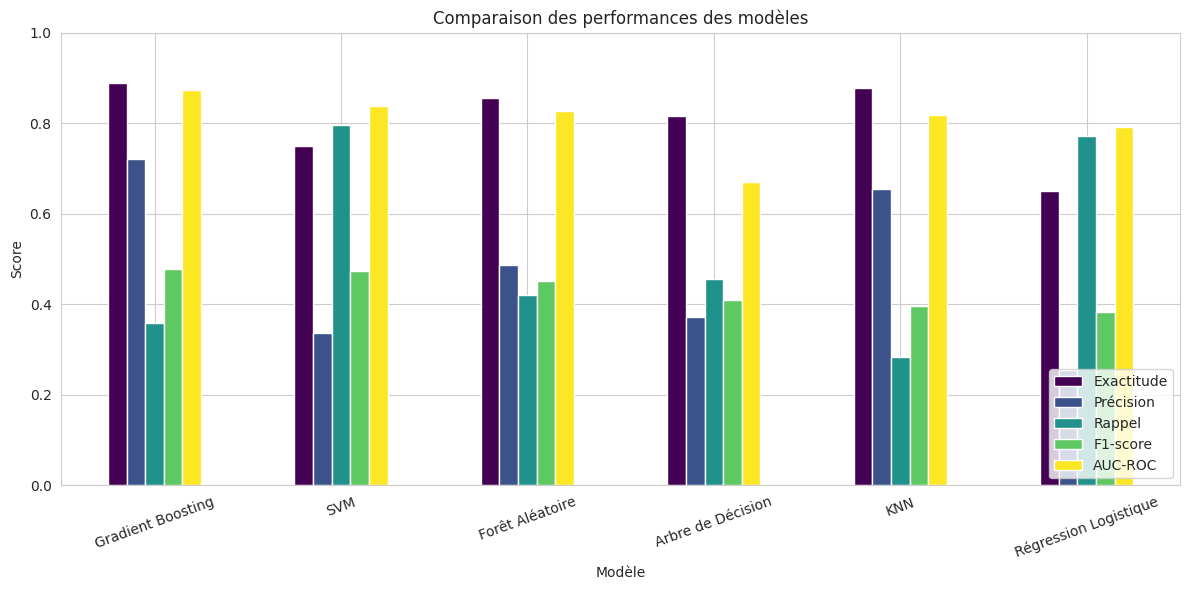

In [ ]:
df_plot = df_resultats.set_index("Modèle")[["Exactitude", "Précision", "Rappel", "F1-score", "AUC-ROC"]]

ax = df_plot.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 10. Sélection et évaluation du meilleur modèle

In [ ]:
meilleur_nom = df_resultats.iloc[0]["Modèle"]
meilleur_modele = modeles_entraines[meilleur_nom]

print(f"🏆 Meilleur modèle : {meilleur_nom}")
print(df_resultats.iloc[0])

y_pred_final = meilleur_modele.predict(X_test_scaled)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_final, target_names=["Non", "Oui"]))


🏆 Meilleur modèle : Gradient Boosting
Modèle        Gradient Boosting
Exactitude             0.890117
Précision              0.720365
Rappel                 0.358006
F1-score               0.478305
AUC-ROC                0.873335
Name: 0, dtype: object

Rapport de classification :
              precision    recall  f1-score   support

         Non       0.90      0.98      0.94      4043
         Oui       0.72      0.36      0.48       662

    accuracy                           0.89      4705
   macro avg       0.81      0.67      0.71      4705
weighted avg       0.88      0.89      0.87      4705



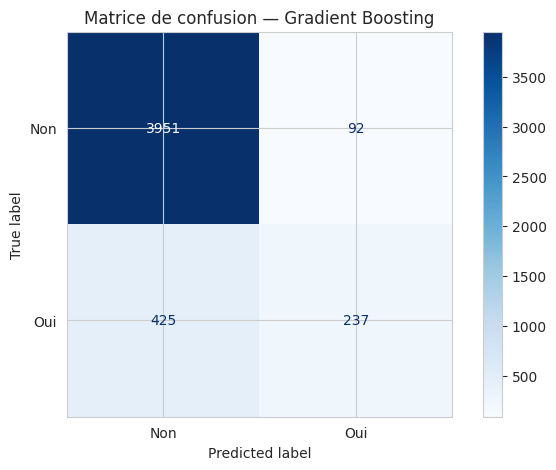

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non", "Oui"])
disp.plot(cmap="Blues")
plt.title(f"Matrice de confusion — {meilleur_nom}")
plt.show()


## 11. Importance des variables (facteurs les plus influents)

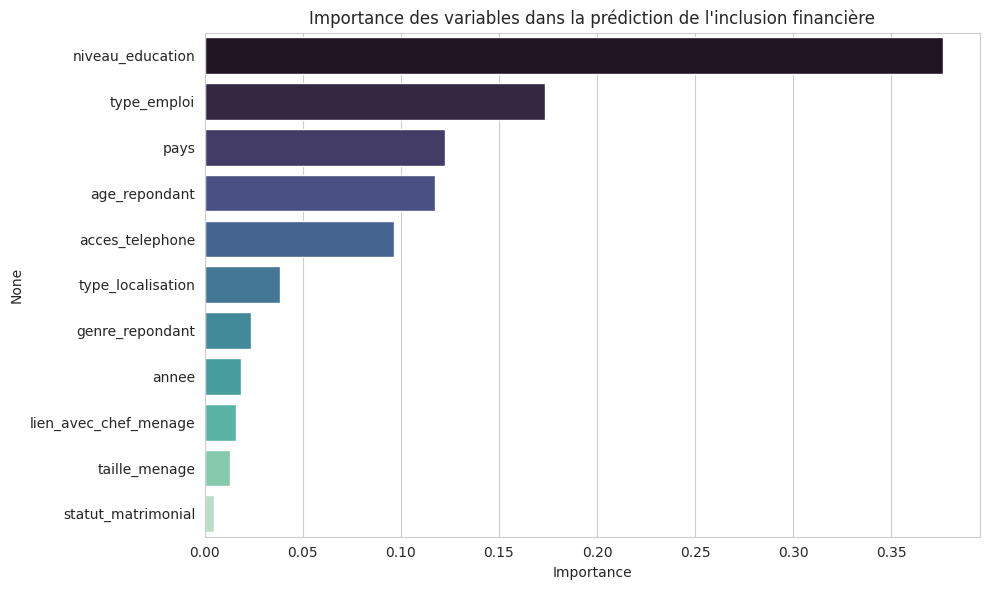

,0
niveau_education,0.376574
type_emploi,0.173716
pays,0.122404
age_repondant,0.117402
acces_telephone,0.096456
type_localisation,0.038215
genre_repondant,0.023671
annee,0.018451
lien_avec_chef_menage,0.015858
taille_menage,0.012807


In [ ]:
if hasattr(meilleur_modele, "feature_importances_"):
    importances = pd.Series(meilleur_modele.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)
else:
    # Repli sur la Forêt Aléatoire si le meilleur modèle ne fournit pas d'importances natives
    rf_ref = modeles_entraines["Forêt Aléatoire"]
    importances = pd.Series(rf_ref.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Importance des variables dans la prédiction de l'inclusion financière")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 12. Conclusion

- Plusieurs modèles de Machine Learning ont été entraînés et comparés (Régression Logistique, Arbre de Décision, Forêt Aléatoire, Gradient Boosting, KNN, SVM).
- Le modèle affiché en tête du tableau de comparaison (section 8) obtient les meilleures performances globales selon le F1-score.
- Les variables les plus influentes dans la prédiction de la possession d'un compte bancaire (proxy de l'inclusion financière) sont visibles dans le graphique d'importance ci-dessus — généralement le niveau d'éducation, le type d'emploi, l'âge et l'accès à un téléphone portable jouent un rôle majeur.
- Ces résultats peuvent aider les décideurs et institutions financières à cibler les populations les moins incluses financièrement (ex : zones rurales, faible niveau d'éducation, absence de téléphone portable) afin d'orienter des politiques d'inclusion financière adaptées, notamment pour les micro-entrepreneurs.

### Pistes d'amélioration
- Optimisation des hyperparamètres (GridSearchCV / RandomizedSearchCV)
- Gestion plus fine du déséquilibre de classes (SMOTE)
- Test d'autres modèles (XGBoost, LightGBM, réseaux de neurones)
- Validation croisée pour une estimation plus robuste des performances
